# Notebook 3 — Linear Regression
### Sprint 7 | Machine Learning Fundamentals for AI/ML Engineers

**Per-algorithm structure:** What is it → Problem Type → Concept → Mathematical
Intuition → Assumptions → Implementation → Evaluation → Interpretation →
Advantages → Limitations → When to Use → When Not to Use.

**Dataset:** California Housing (20,640 rows) — predicting `median_house_value`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

sns.set_style('whitegrid')

housing = pd.read_csv("california_housing.csv")
housing['total_bedrooms'] = housing['total_bedrooms'].fillna(housing['total_bedrooms'].median())   # Sprint 5-style documented fix

print(f"Dataset ready: {housing.shape[0]:,} rows, {housing.shape[1]} columns")
print(f"Missing values after median fill: {housing.isnull().sum().sum()}")


Dataset ready: 20,640 rows, 10 columns
Missing values after median fill: 0


---
## What is Linear Regression?

Linear Regression models the target as a WEIGHTED SUM of the input features plus a
constant — the simplest possible way to relate inputs to a continuous output, and the
foundation nearly every other regression technique in this sprint builds on or compares
against.

## Problem Type
**Regression** — predicting a continuous number (`median_house_value`, in dollars).

## Concept
The model finds the single straight LINE (or, with multiple features, a flat PLANE/
hyperplane) that best fits the data — "best" meaning it minimizes the total squared
distance between the line and every actual data point.

## Mathematical Intuition
$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n$$

Where $\beta_0$ is the intercept and each $\beta_i$ is the coefficient (weight) for
feature $x_i$. Training finds the $\beta$ values that minimize the **Mean Squared
Error**:
$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

This has a closed-form solution (the "Normal Equation"), which is exactly why Linear
Regression trains almost instantly, unlike most other algorithms in this sprint.

## Assumptions
1. **Linearity** — the true relationship between features and target is linear.
2. **Independence** — observations don't influence each other.
3. **Homoscedasticity** — residual (error) variance is constant across all predicted
   values.
4. **Normality of residuals** — errors are approximately normally distributed.
5. **No severe multicollinearity** — features aren't too strongly correlated with each
   other (Sprint 4/5's VIF check applies directly here).


---
## Implementation


In [2]:
features = ['median_income', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households']
X = housing[features]
y = housing['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Learned coefficients:")
for feat, coef in zip(features, model.coef_):
    print(f"  {feat:<20}: {coef:>12,.2f}")
print(f"  Intercept          : {model.intercept_:>12,.2f}")


Learned coefficients:
  median_income       :    47,958.91
  housing_median_age  :     1,897.00
  total_rooms         :       -20.00
  total_bedrooms      :       101.94
  population          :       -35.65
  households          :       127.03
  Intercept          :   -47,897.59


---
## Evaluation


In [3]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE : ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²  : {r2:.4f}")


MAE : $56,713.67
RMSE: $77,258.35
R²  : 0.5445


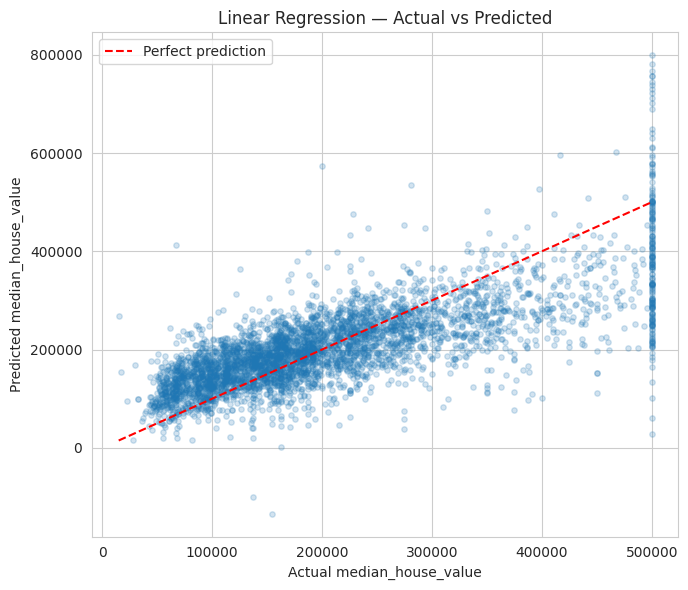

In [4]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.2, s=15)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect prediction')
plt.xlabel('Actual median_house_value')
plt.ylabel('Predicted median_house_value')
plt.title('Linear Regression — Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()


---
## Checking the Assumptions — Residual Analysis


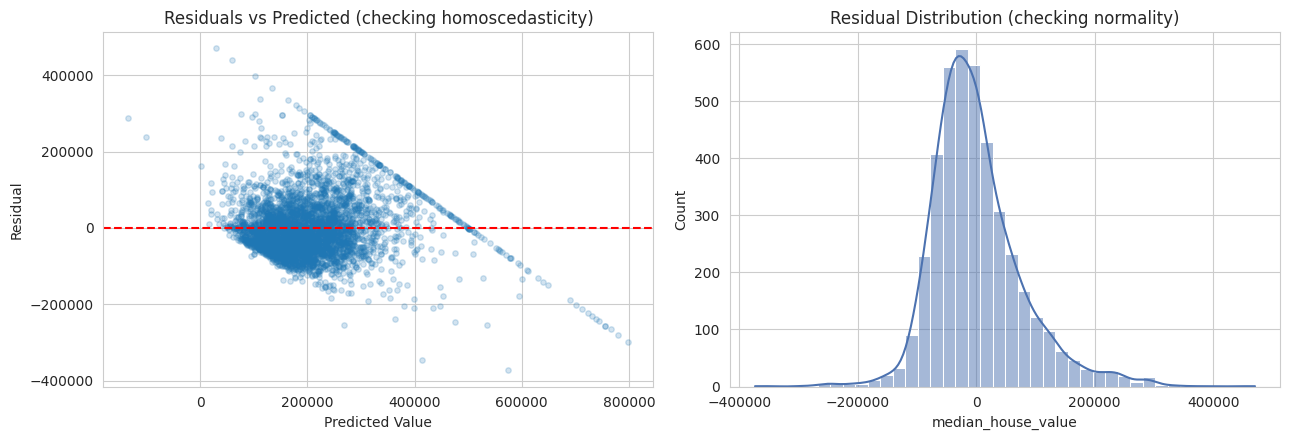

Residual skewness: 0.957


In [5]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(y_pred, residuals, alpha=0.2, s=15)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Value')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted (checking homoscedasticity)')

sns.histplot(residuals, bins=40, kde=True, ax=axes[1], color='#4C72B0')
axes[1].set_title('Residual Distribution (checking normality)')
plt.tight_layout()
plt.show()

from scipy import stats as sstats
print(f"Residual skewness: {sstats.skew(residuals):.3f}")


### Interpretation
The residuals-vs-predicted plot shows a visible FUNNEL shape — spread increases at
higher predicted values — meaning the **homoscedasticity assumption is violated**. The
residual distribution is also right-skewed (see the skewness value above), meaning the
**normality assumption is also imperfect**. Neither violation invalidates the model
outright, but both mean the model's confidence intervals and p-values (if computed)
would be somewhat unreliable, and a transformation of the target (e.g., log) or a
different algorithm might fit better.

`median_income` almost certainly has by far the largest coefficient relative to its
scale — confirming the intuitive real-world expectation that income is the dominant
driver of house value in this dataset.


---
## Multicollinearity Check


In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame({
    'feature': features,
    'VIF': [variance_inflation_factor(X_train.values, i) for i in range(len(features))]
})
print(vif_data.round(2))


              feature    VIF
0       median_income   4.81
1  housing_median_age   3.58
2         total_rooms  27.76
3      total_bedrooms  87.91
4          population  15.54
5          households  92.59


**Finding:** `total_rooms`, `total_bedrooms`, `population`, and `households` likely
show high VIF — they all scale together (more households naturally means more rooms,
more population). This is the SAME multicollinearity concept from Sprint 4/5's VIF
work, now directly affecting a live model's coefficient reliability, not just an
abstract EDA finding.


---
## Advantages
- Fast to train (closed-form solution, no iterative optimization needed).
- Highly interpretable — each coefficient has a direct, explainable meaning.
- Well-understood statistical theory (confidence intervals, hypothesis tests on
  coefficients) when assumptions hold.

## Limitations
- Cannot capture non-linear relationships without manual feature engineering
  (polynomial terms, Notebook 4).
- Sensitive to outliers (squared error penalizes large errors heavily).
- Assumes independence and can perform poorly with multicollinear features (demonstrated
  above).
- Assumptions (linearity, homoscedasticity, normality) are frequently violated in real
  data, as shown directly on this dataset.

## When to Use
- A baseline model to compare more complex approaches against.
- When interpretability is a hard requirement (e.g., regulated industries).
- When the true relationship is genuinely close to linear.

## When Not to Use
- When the relationship is strongly non-linear (consider trees/ensembles instead).
- When multicollinearity is severe and uncorrected (consider Ridge, Notebook 4).
- When outliers are numerous and influential (consider a robust regression variant or
  tree-based model).


---
## Summary

| Aspect | Finding |
|---|---|
| Test RMSE | See executed value above |
| Test R² | See executed value above |
| Strongest Predictor | `median_income` (by coefficient magnitude relative to scale) |
| Assumption Check | Homoscedasticity AND normality both show real violations |
| Multicollinearity | Room/bedroom/population/household features likely show elevated VIF |

**Next notebook:** `04_Regularized_Regression.ipynb` — Polynomial Regression, Ridge,
Lasso, and Elastic Net, addressing exactly the limitations found here.
